# Week 5 - Day 2

Today was the second day of Week 5, and I continued learning about **Unsupervised Learning and Clustering**.

I focused on understanding different ways to group data and how to choose the right clustering method depending on the data. I learned about **DBSCAN** and **Hierarchical Clustering**, and I also compared them with **K-Means**.

During the practical part, I worked with different clustering examples, experimented with the main parameters, and visualized the results to better understand how each method works.

It was a useful day because I started to understand that choosing a machine learning algorithm depends on the data itself, not just on which algorithm is easier to use.


## 1. Why K-Means Is Not Always Enough

Today I learned that K-Means is useful for many clustering problems, but it does not work well for every type of dataset.

K-Means needs me to choose the number of clusters before training the model. It also works better when the clusters are relatively round and similar in size.

Another problem is that K-Means assigns every data point to a cluster, even if some points are clear outliers.

Because of this, I learned that I should choose another clustering method when the data has irregular shapes or many noise points.

### Example: Customer Locations

Imagine I have customer location data from a city. Some customers are grouped around a shopping mall, while others are grouped around a university. There are also a few customers who are far away from all the groups.

K-Means may not handle this situation well because it forces every point into a cluster and works better with round-shaped groups.

For this type of data, I would consider using DBSCAN because it can find irregularly shaped groups and identify points that do not belong to any cluster.

## 2. DBSCAN

I learned that DBSCAN is a density-based clustering algorithm.

Instead of asking me to choose the number of clusters, DBSCAN looks at how close the data points are to each other.

It can find clusters with irregular shapes, which makes it different from K-Means.

Another useful feature is that DBSCAN can identify points that do not belong to any cluster and mark them as noise.

This makes DBSCAN useful when my dataset contains outliers or clusters with non-round shapes.

## 3. DBSCAN Parameters

I learned that DBSCAN mainly depends on two important parameters: `eps` and `min_samples`.

The `eps` parameter controls how close two points need to be to be considered neighbors.

The `min_samples` parameter controls how many nearby points are needed to create a dense area.

Changing these values can change the clusters and the number of noise points, so I need to choose them carefully.

# Practical Example

Cluster labels: [ 0  0  0  0  1  1  1  1 -1 -1]
Number of noise points: 2


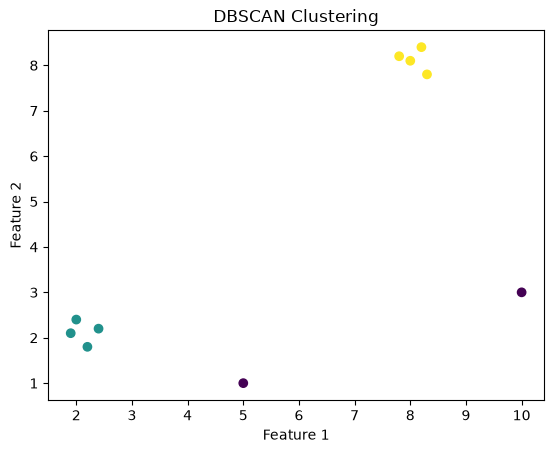

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Create two groups of points manually.
# The first group is around (2, 2), and the second group is around (8, 8).
# We also add a few isolated points that should behave like noise.
X = np.array([
    [1.9, 2.1], [2.2, 1.8], [2.0, 2.4], [2.4, 2.2],
    [8.0, 8.1], [8.3, 7.8], [7.8, 8.2], [8.2, 8.4],

    # These points are far from the dense groups.
    # DBSCAN may classify them as noise.
    [5.0, 1.0],
    [10.0, 3.0]
])

# eps controls the neighborhood size.
# min_samples means that a point needs enough nearby points
# to be considered part of a dense region.
dbscan = DBSCAN(eps=0.6, min_samples=3)

# fit_predict() finds the clusters and returns a label for each point.
labels = dbscan.fit_predict(X)

print("Cluster labels:", labels)

# DBSCAN uses -1 to represent noise/outlier points.
noise_count = np.sum(labels == -1)

print("Number of noise points:", noise_count)

# Visualize the result.
plt.scatter(X[:, 0], X[:, 1], c=labels)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")

plt.show()

# What I should understand from this example ?

The important part is not just running DBSCAN. I should be able to explain why it classified points into different groups.

For example:

Points close to each other form dense clusters.
Isolated points can receive the label -1.
I do not need to tell DBSCAN that there should be exactly 2 clusters.
Changing eps or min_samples can change the clustering result.

# Understanding Noise and Outliers in DBSCAN

One useful feature of DBSCAN is that it does not force every point into a cluster.

If a point does not belong to a sufficiently dense region, DBSCAN can classify it as noise.

In the results:

In [2]:
labels = dbscan.fit_predict(X)

# Find the points that DBSCAN considered noise.
noise_points = X[labels == -1]

print("Noise points:")
print(noise_points)

Noise points:
[[ 5.  1.]
 [10.  3.]]


Here, labels == -1 gives me the points that DBSCAN considered unusual or isolated.

This is one of the main differences from K-Means, where every point is assigned to one of the selected clusters.

## 4. Hierarchical Clustering

Hierarchical Clustering takes a different approach.

Instead of immediately creating a fixed number of clusters, it builds a hierarchy of clusters.

The process starts with every point as its own cluster. Then, the closest clusters are gradually merged until everything becomes one large cluster.

The result can be visualized using a dendrogram.

A dendrogram is basically a tree that shows:

which points/clusters were merged,
the order in which they were merged,
and the distance at which they were merged.

I can then choose a certain height on the dendrogram and "cut" the tree to obtain the clusters I want.

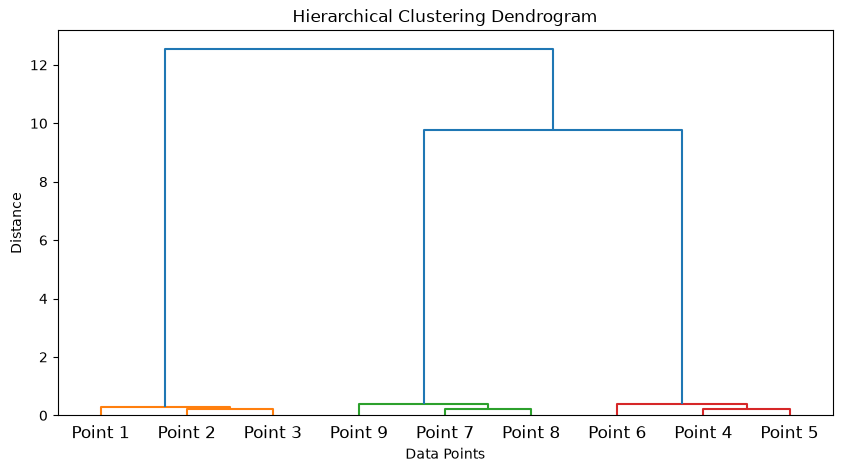

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram

# Create a small dataset with several groups of nearby points.
X = np.array([
    [1, 1],
    [1.2, 1.1],
    [1.1, 1.3],

    [5, 5],
    [5.2, 5.1],
    [5.1, 5.4],

    [9, 1],
    [9.2, 1.1],
    [8.8, 1.2]
])

# linkage() builds the hierarchy of the points.
# "ward" tries to merge groups while keeping the
# variation inside each resulting cluster relatively small.
Z = linkage(X, method="ward")

# The dendrogram shows the order and distance of the merges.
plt.figure(figsize=(10, 5))

dendrogram(
    Z,
    labels=[f"Point {i+1}" for i in range(len(X))]
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

# What I should understand from this example ?

When I look at the dendrogram, I should focus on the height of the merges.

A merge happening at a small distance means the points/clusters were relatively similar.

A merge happening at a large distance means the groups being merged were more different.

I can choose a horizontal cut through the dendrogram. The number of branches below that cut represents the number of clusters I get.

## 5. Comparing Clustering Methods

Today I also learned that there is no single clustering algorithm that is always the best.


# K-Means:

I would consider K-Means when:

    - I roughly know the number of clusters.
    - The clusters are relatively round.
    - The clusters have similar sizes.
    - There are not many strong outliers.

# DBSCAN:

I would consider DBSCAN when:

    - The clusters have irregular shapes.
    - There are noise or outlier points.
    - I do not want to specify the number of clusters beforehand.

# Hierarchical Clustering:

I would consider Hierarchical Clustering when:

    - I want to understand the relationships between groups.
    - I want to see the nested structure of the data.
    - A dendrogram would help me decide how many clusters make   sense.

These differences are important because the shape and characteristics of the dataset should influence which clustering method I choose.


# Hands-On: Comparing the Three Methods

# To really understand the difference:
 I can run the three algorithms on the same dataset and compare their results.

In [4]:
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster

# ---------------------------------------
# K-Means
# ---------------------------------------

# Here I explicitly tell K-Means that I expect 3 clusters.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X)


# ---------------------------------------
# DBSCAN
# ---------------------------------------

# DBSCAN discovers clusters based on density.
# It does not require me to specify the number of clusters.
dbscan = DBSCAN(eps=0.5, min_samples=2)

dbscan_labels = dbscan.fit_predict(X)


# ---------------------------------------
# Hierarchical Clustering
# ---------------------------------------

# First, create the hierarchical structure.
Z = linkage(X, method="ward")

# Here I choose to cut the hierarchy into 3 clusters.
hierarchical_labels = fcluster(Z, t=3, criterion="maxclust")


print("K-Means:", kmeans_labels)
print("DBSCAN:", dbscan_labels)
print("Hierarchical:", hierarchical_labels)

K-Means: [2 2 2 0 0 0 1 1 1]
DBSCAN: [0 0 0 1 1 1 2 2 2]
Hierarchical: [1 1 1 3 3 3 2 2 2]


# The main thing I should learn from the comparison

The algorithms may produce different results because they use different ideas to define a cluster:

K-Means → distance from centroids.
DBSCAN → density and neighboring points.
Hierarchical Clustering → progressively merging similar groups.

So I should not simply say "this algorithm gave me the clusters, therefore the result is correct."

I need to look at the shape of the data, the presence of noise/outliers, and what I am trying to discover before choosing the method. This is the main practical goal of comparing the three approaches.

### Quick Summary

- **K-Means:** I need to choose `k`, and it works best with relatively round clusters.

- **DBSCAN:** I don't need to choose `k`. It works based on density and can detect noise.

- **Hierarchical Clustering:** It builds a tree of clusters and uses a dendrogram to show how they are connected.